## Sorry AI — You Still Can’t take these”

A peek into the change of skills in demand in the recent years and how you can prepare yourself for it!

In [2]:
## first, importing the basic libraries!
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from glob import glob
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose



In [5]:
## combining the postings individual linkedin datasets into one
folder_path_s = "H1B_Newsletter/individual_user_skill" 


# Find all CSV files (including subfolders if any)
csv_files_skill = glob(f"{folder_path_s}/**/*.csv", recursive=True)

print(f"Found {len(csv_files_skill)} CSV files")

# Load and combine them all
skills_df = pd.concat(
    (pd.read_csv(f) for f in csv_files_skill),
    ignore_index=True
)

print("Combined shape:", skills_df.shape)
print("Columns:", skills_df.columns.tolist())

Found 48 CSV files
Combined shape: (91972181, 4)
Columns: ['user_id', 'skill_raw', 'skill_mapped', 'skill_k75']


In [6]:
# ================== Save as one CSV ==================
output_filename = "all_skills_combined.csv"

skills_df.to_csv(output_filename, index=False)

print(f" Successfully saved as '{output_filename}'")
print(f"File size: {skills_df.shape[0]:,} rows × {skills_df.shape[1]} columns")

 Successfully saved as 'all_skills_combined.csv'
File size: 91,972,181 rows × 4 columns


In [2]:
monthly_postings = pd.read_csv("CSV_files/postings_combined.csv")

In [8]:
## combining the postings individual linkedin datasets into one
folder_path_ct = "H1B_Newsletter/wf_dynam_role_breakdown" 


# Find all CSV files (including subfolders if any)
csv_files_count = glob(f"{folder_path_ct}/**/*.csv", recursive=True)

print(f"Found {len(csv_files_count)} CSV files")

# Load and combine them all
count_df = pd.concat(
    (pd.read_csv(f) for f in csv_files_count),
    ignore_index=True
)

print("Combined shape:", count_df.shape)
print("Columns:", count_df.columns.tolist())

Found 32 CSV files
Combined shape: (10239812, 17)
Columns: ['rcid', 'company', 'region', 'seniority', 'role_k10', 'role_k50', 'role_k150', 'month', 'count', 'inflow', 'outflow', 'external_inflow', 'external_outflow', 'salary', 'duration', 'total_prestige', 'prestige_weight']


In [9]:
# ================== Save as one CSV ==================
output = "wf_count.csv"

count_df.to_csv(output, index=False)

print(f" Successfully saved as '{output}'")
print(f"File size: {count_df.shape[0]:,} rows × {count_df.shape[1]} columns")

 Successfully saved as 'wf_count.csv'
File size: 10,239,812 rows × 17 columns


In [3]:
print(count_df.head())
print(monthly_postings.head())

NameError: name 'count_df' is not defined

In [11]:
company_mapping= pd.read_csv("CSV_files/company_mapping.csv")

In [12]:
print(monthly_postings['company'].unique())

<StringArray>
[             'Microsoft Corp.',             'Activision, Inc.',
 'Advanced Micro Devices, Inc.',                 'NVIDIA Corp.',
                   'Google LLC',         'Meta Platforms, Inc.',
                    'Waymo LLC',                  'Intel Corp.',
                 'Google Cloud',        'Playground Games Ltd.',
 ...
       'JML International Ltd.', 'Plexo Capital Management LLC',
                'Airsoft, Inc.',    'Ready at Dawn Studios LLC',
   'Intel Technology Sdn. Bhd.',        'Neverware Europe Ltd.',
                 'Fitbit, Inc.',                   'BOPS, Inc.',
             'Softricity, Inc.',        'GV Management Co. LLC']
Length: 158, dtype: str


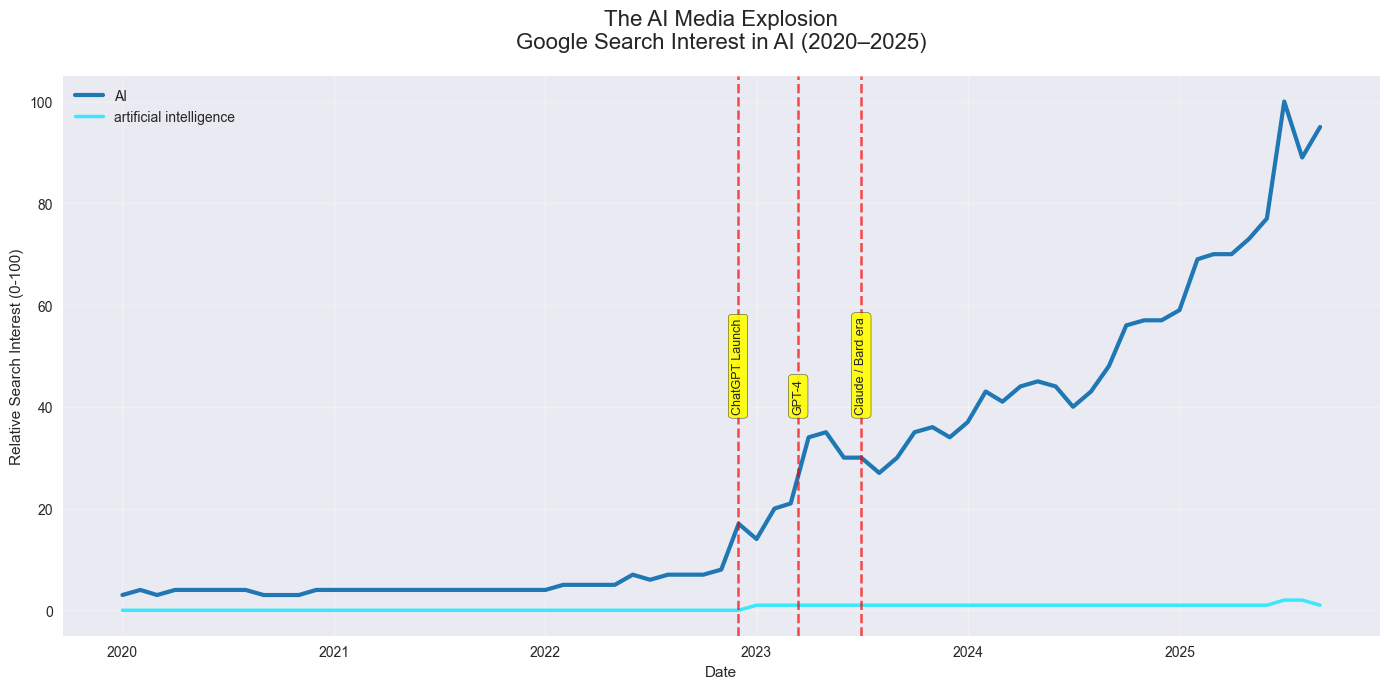

In [3]:
## we will be looking at "AI/artificail intelligence" trends in news headlines
plt.style.use('seaborn-v0_8')

# Fetch Google Trends data
pytrends = TrendReq(hl='en-US', tz=360)
pytrends.build_payload(["AI", "artificial intelligence"], 
                       timeframe='2020-01-01 2025-09-07', 
                       geo='US')

df_ai = pytrends.interest_over_time()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_ai.index, df_ai['AI'], label='AI', linewidth=3, color='#1f77b4')
ax.plot(df_ai.index, df_ai['artificial intelligence'], label='artificial intelligence', 
        linewidth=2.5, color="#0ee7ff", alpha=0.8)
# Key AI milestones
events = {
    'ChatGPT Launch': '2022-11-30',
    'GPT-4': '2023-03-14',
    'Claude / Bard era': '2023-07-01'
}

for label, date_str in events.items():
    date = datetime.datetime.strptime(date_str, '%Y-%m-%d')
    ax.axvline(x=date, color='red', linestyle='--', linewidth=1.8, alpha=0.7)
    ax.annotate(label, xy=(date, 35), xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=9, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.9))

ax.set_title("The AI Media Explosion\nGoogle Search Interest in AI (2020–2025)", fontsize=16, pad=20)
ax.set_xlabel("Date")
ax.set_ylabel("Relative Search Interest (0-100)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
plt.style.use('seaborn-v0_8')

postings_monthly = pd.read_csv('CSV_files/postings_combined.csv')
# Use the postings dataframe you already have open
df = postings_monthly.copy()
df_clean = df[df['role_k10'] != 'unknown'].copy() ## I will be removing any role that doesn't have a knwon role

# Calculate filling time
df_clean['post_date'] = pd.to_datetime(df_clean['post_date'], errors='coerce')
df_clean['remove_date'] = pd.to_datetime(df_clean['remove_date'], errors='coerce')
df_clean['filling_time_days'] = (df_clean['remove_date'] - df_clean['post_date']).dt.days
df_clean['filling_time_months'] = df_clean['filling_time_days'] / 30.44

df_clean['Month'] = df_clean['post_date'].dt.to_period('M').dt.to_timestamp()

monthly = df_clean.groupby('Month').agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index()

monthly = monthly.set_index('Month')

# Seasonal adjustment
decomp = seasonal_decompose(monthly['Filling_time_avg'], model='additive', period=12)
monthly['Filling_time_seasonally_adjusted'] = monthly['Filling_time_avg'] - decomp.seasonal

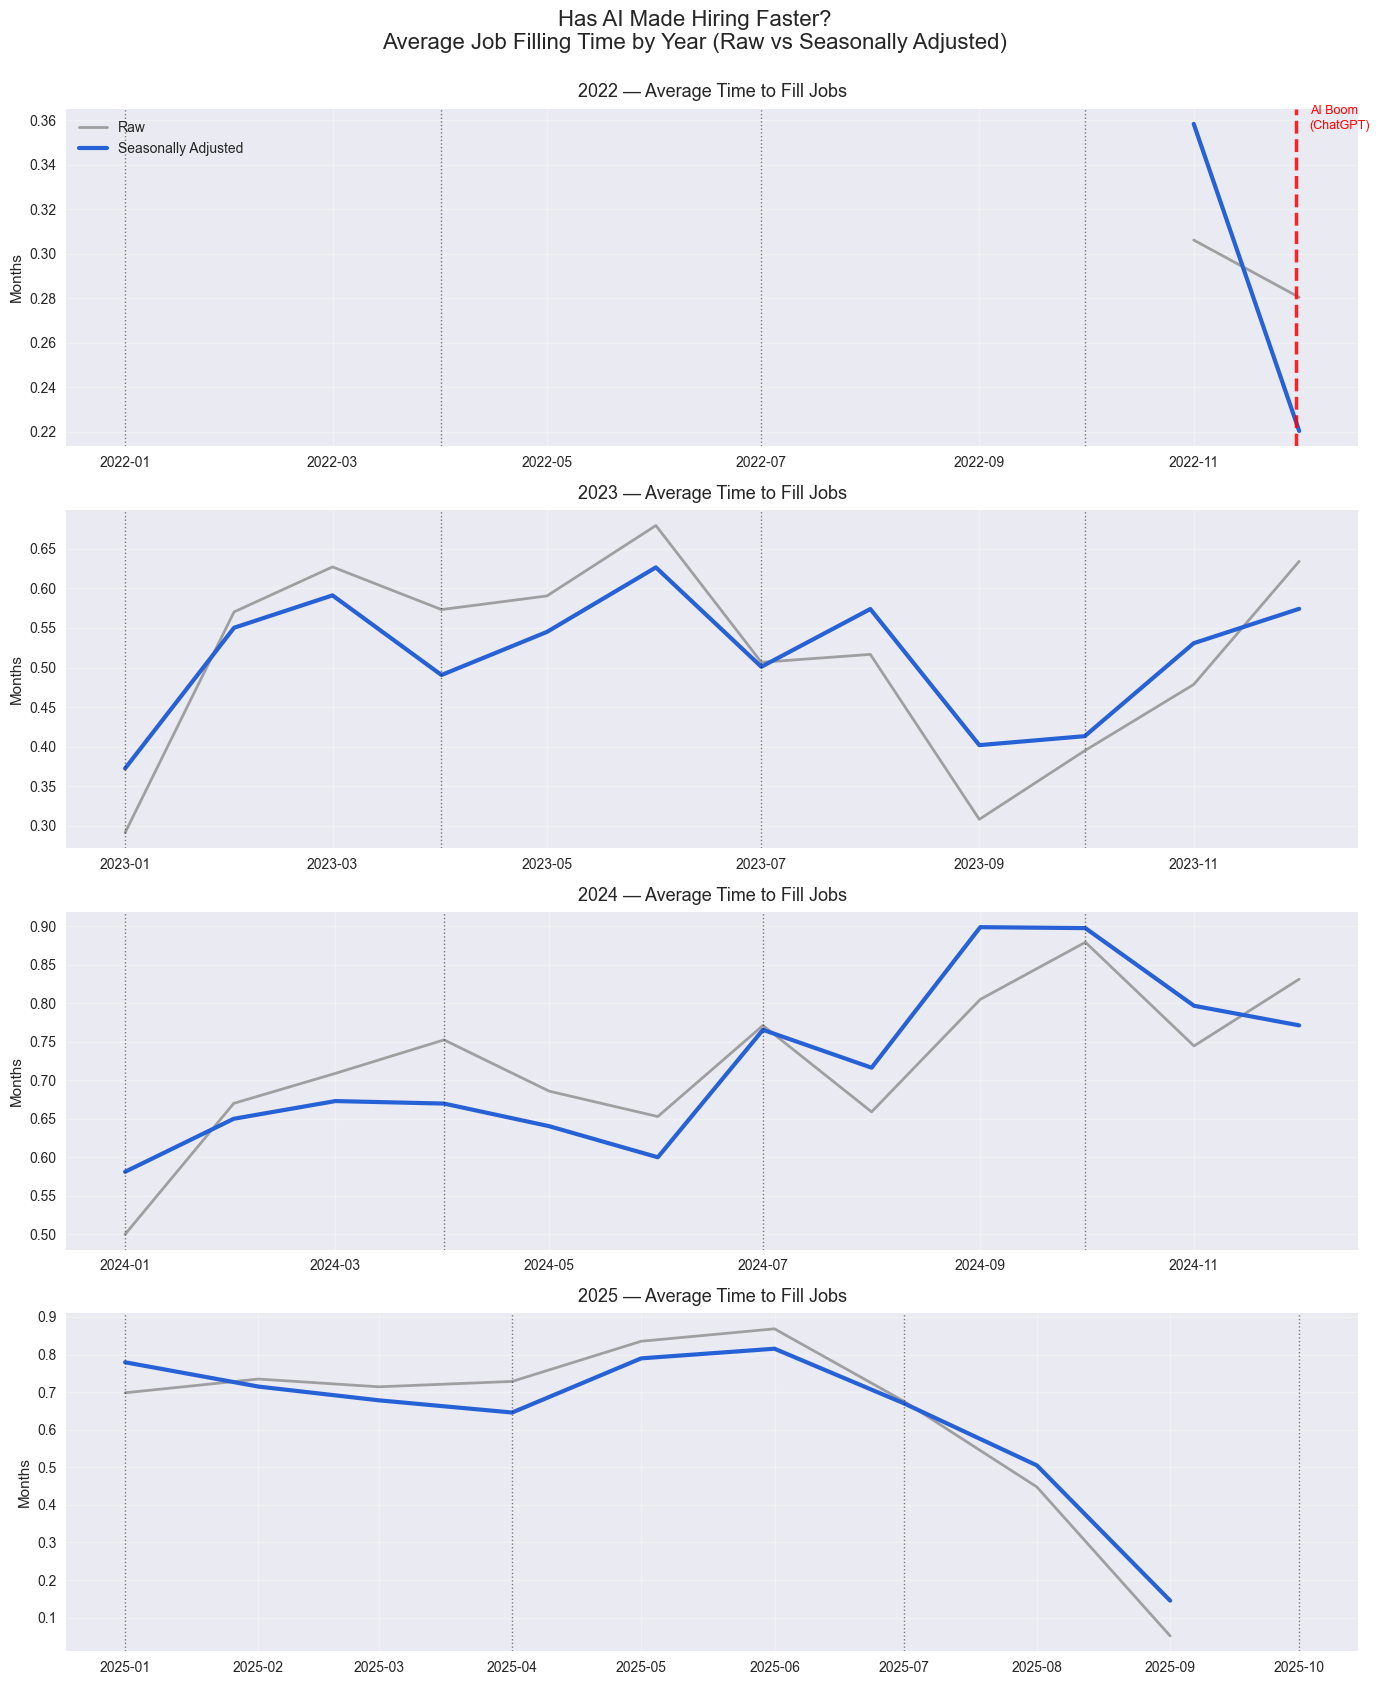

In [7]:
# ================== Plot with Unified Quarters ==================
years = [2022, 2023, 2024, 2025]   # you can change this list
fig, axes = plt.subplots(len(years), 1, figsize=(14, 4.2 * len(years)), sharey=False)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter data for this year
    year_data = monthly[monthly.index.year == year].copy()
    
    # Plot both series
    ax.plot(year_data.index, year_data['Filling_time_avg'], 
            label='Raw', linewidth=2, color='gray', alpha=0.7)
    ax.plot(year_data.index, year_data['Filling_time_seasonally_adjusted'], 
            label='Seasonally Adjusted', linewidth=3, color="#2761d6")
    
    # === Unified Quarter Lines (always Jan, Apr, Jul, Oct) ===
    for q in [1, 4, 7, 10]:   # start of each quarter
        q_date = pd.Timestamp(f"{year}-{q:02d}-01")
        ax.axvline(x=q_date, color='black', linestyle=':', alpha=0.5, linewidth=1)
    
    # Title and labels
    ax.set_title(f"{year} — Average Time to Fill Jobs", fontsize=13, pad=8)
    ax.set_ylabel("Months")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

    # Highlight AI Boom in 2022
    if year == 2022:
        ai_date = datetime.datetime(2022, 11, 30)
        ax.axvline(x=ai_date, color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom\n(ChatGPT)', xy=(ai_date, 0.35), 
                    xytext=(10, 10), textcoords='offset points', 
                    fontsize=9, color='red')

# Overall title
fig.suptitle("Has AI Made Hiring Faster?\nAverage Job Filling Time by Year (Raw vs Seasonally Adjusted)", 
             fontsize=16, y=1)

plt.tight_layout()
plt.show()

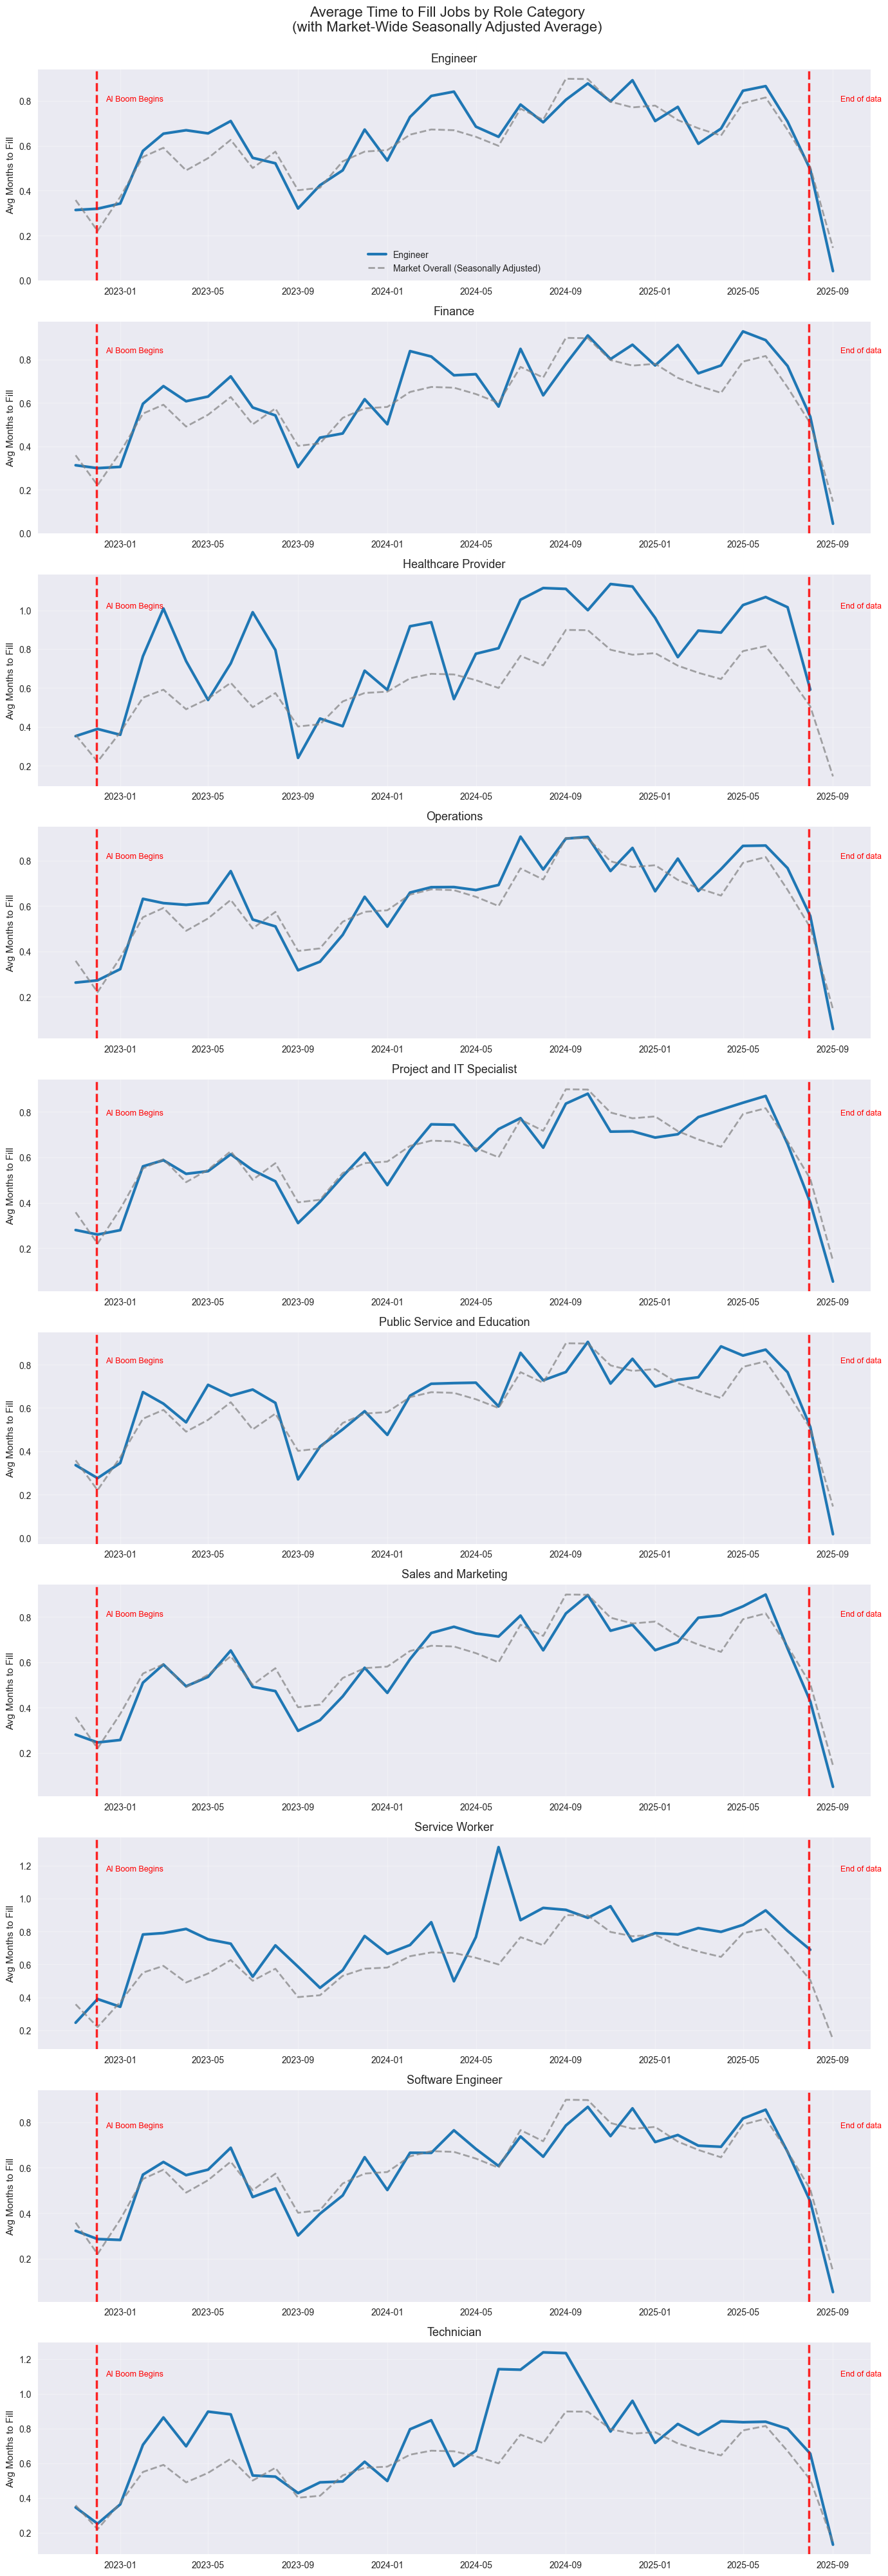

In [11]:
# Monthly per-role data
monthly_role = df_clean.groupby(['Month', 'role_k10']).agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index()

# Overall seasonally adjusted average (market-wide)
monthly_overall = df_clean.groupby('Month').agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index().set_index('Month')

decomp = seasonal_decompose(monthly_overall['Filling_time_avg'], model='additive', period=12)
monthly_overall['Filling_time_seasonally_adjusted'] = monthly_overall['Filling_time_avg'] - decomp.seasonal

# ================== Subplots with grey overall line ==================
roles = sorted(monthly_role['role_k10'].unique())
fig, axes = plt.subplots(len(roles), 1, figsize=(14, 4 * len(roles)), sharex=False)

for i, role in enumerate(roles):
    ax = axes[i]
    data = monthly_role[monthly_role['role_k10'] == role]
    
    # Role-specific line
    ax.plot(data['Month'], data['Filling_time_avg'], 
            label=role, linewidth=3, color='#1f77b4')
    
    # Grey overall seasonally adjusted line
    ax.plot(monthly_overall.index, monthly_overall['Filling_time_seasonally_adjusted'], 
            label='Market Overall (Seasonally Adjusted)', 
            linewidth=2, color='gray', alpha=0.7, linestyle='--')
    
    ax.set_title(f"{role}", fontsize=13, pad=8)
    ax.set_ylabel("Avg Months to Fill")
    ax.grid(True, alpha=0.3)
    
    if i == 0:  # legend only on first subplot
        ax.legend()

    # AI Boom marker
    if 2022 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2022, 11, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom Begins', xy=(datetime.datetime(2022, 11, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')
    ## end marker
    if 2025 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2025, 7, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('End of data', 
                    xy=(datetime.datetime(2025, 8, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')

fig.suptitle("Average Time to Fill Jobs by Role Category\n(with Market-Wide Seasonally Adjusted Average)", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

Top 10 roles by variability (std dev) of filling time:
                              mean_filling_time  std_filling_time  \
role_k10                                                            
Technician                                0.667             0.636   
Healthcare Provider                       0.722             0.558   
Finance                                   0.632             0.551   
Service Worker                            0.735             0.545   
Operations                                0.614             0.526   
Engineer                                  0.623             0.516   
Public Service and Education              0.608             0.504   
Project and IT Specialist                 0.610             0.439   
Software Engineer                         0.601             0.438   
Sales and Marketing                       0.620             0.434   

                              variance_filling_time  num_jobs  
role_k10                                            

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_39006/3186622795.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


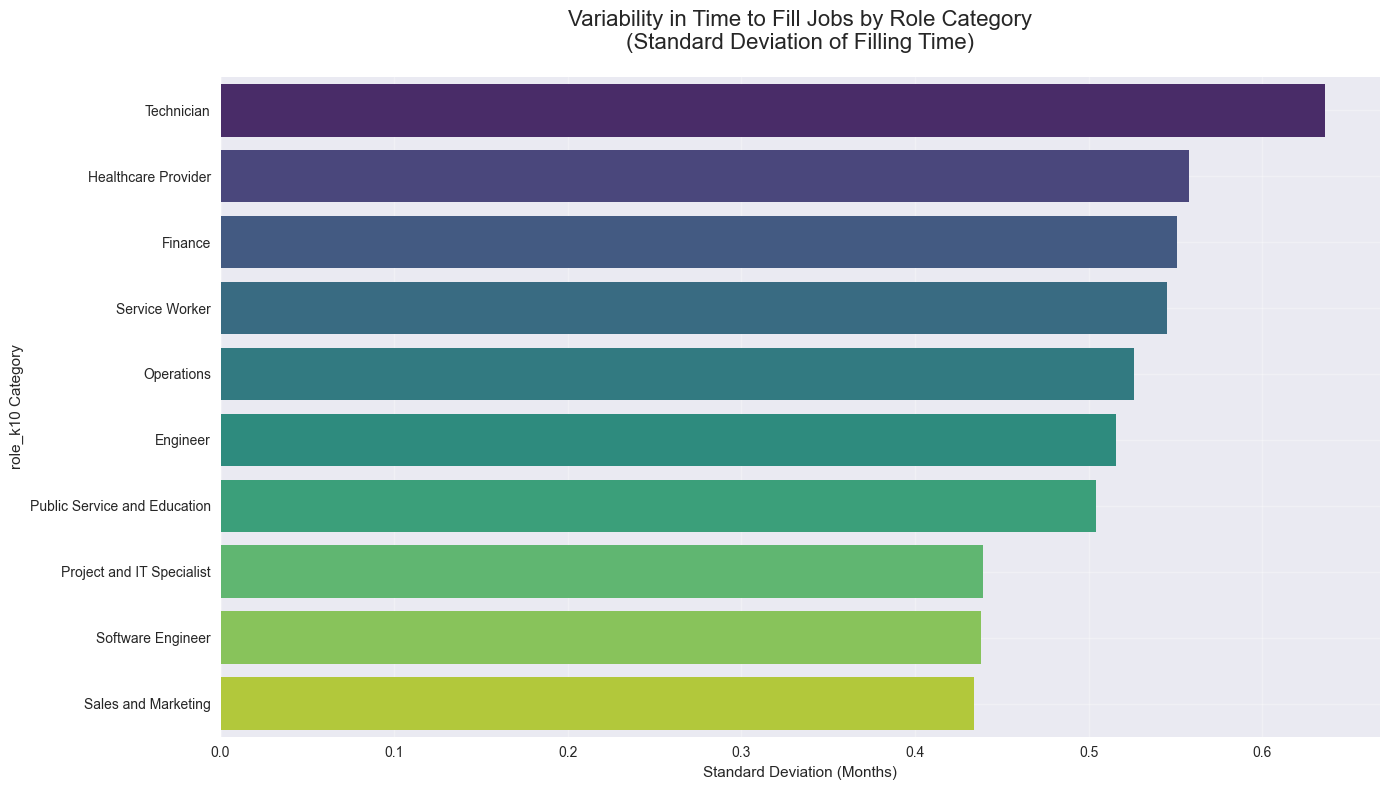

In [12]:
# ================== Variance / Standard Deviation of Time to Fill by Role ==================
# Calculate mean and standard deviation per role
role_stats = df_clean.groupby('role_k10').agg(
    mean_filling_time=('filling_time_months', 'mean'),
    std_filling_time=('filling_time_months', 'std'),
    variance_filling_time=('filling_time_months', 'var'),
    num_jobs=('filling_time_months', 'count')
).round(3)

# Sort by highest variability (standard deviation)
role_stats = role_stats.sort_values('std_filling_time', ascending=False)

print("Top 10 roles by variability (std dev) of filling time:")
print(role_stats.head(10)[['mean_filling_time', 'std_filling_time', 'variance_filling_time', 'num_jobs']])

# ================== Bar Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(
    data=role_stats.reset_index().head(12), 
    x='std_filling_time', 
    y='role_k10',
    palette="viridis"
)

ax.set_title("Variability in Time to Fill Jobs by Role Category\n(Standard Deviation of Filling Time)", 
             fontsize=16, pad=20)
ax.set_xlabel("Standard Deviation (Months)")
ax.set_ylabel("role_k10 Category")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/544785579.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


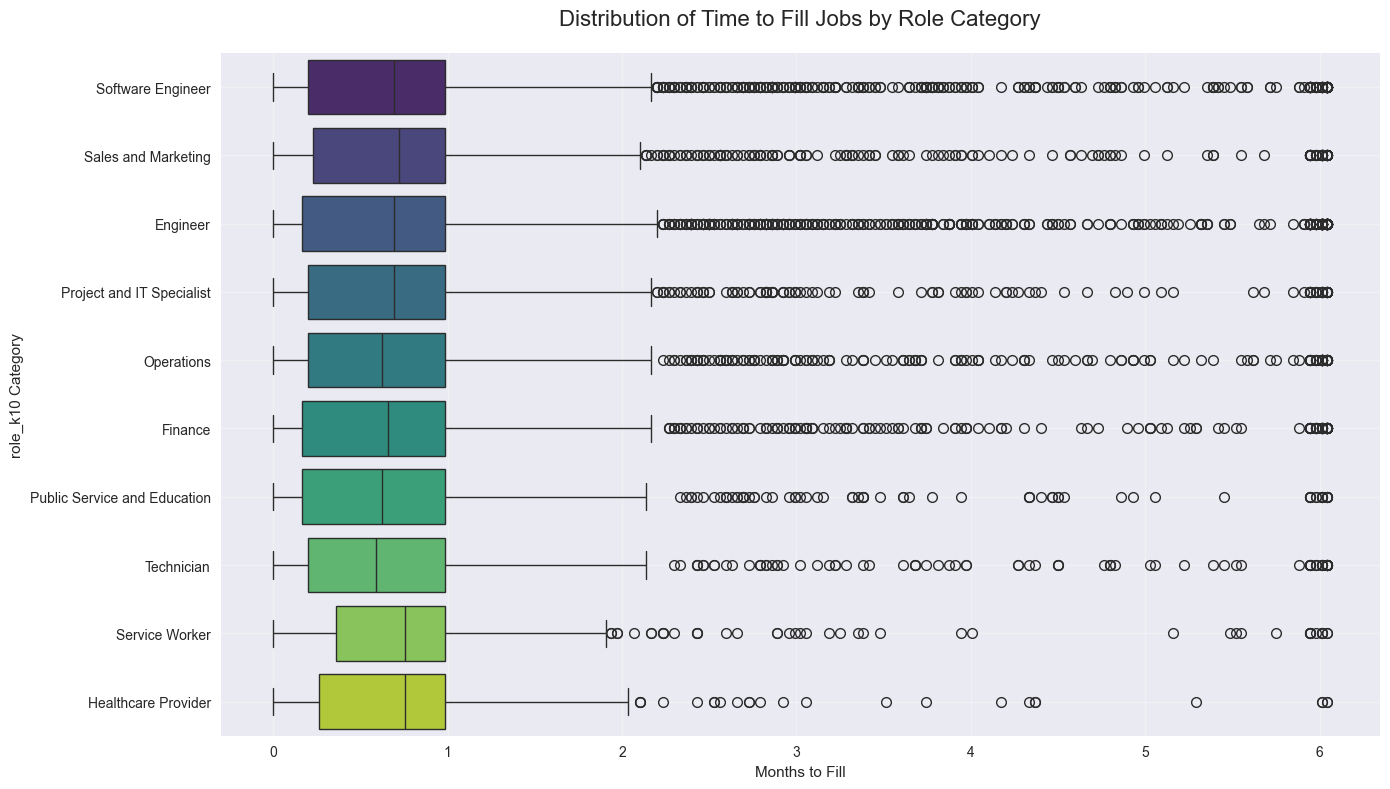

In [ ]:

# Get top 12 most common roles (to keep the plot readable)
top_roles = df_clean['role_k10'].value_counts().head(12).index.tolist()

# Filter to those roles
plot_data = df_clean[df_clean['role_k10'].isin(top_roles)]

# ================== Box Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=plot_data,
    x='filling_time_months',
    y='role_k10',
    order=top_roles,           
    palette="viridis",
    showfliers=True
)

ax.set_title("Distribution of Time to Fill Jobs by Role Category", 
             fontsize=16, pad=20)
ax.set_xlabel("Months to Fill")
ax.set_ylabel("role_k10 Category")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ================== Percentage of Outliers by role_k10 ==================
# Function to count upper outliers
def count_upper_outliers(group):
    if len(group) < 4:
        return 0
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return (group > upper_bound).sum()

# Calculate outliers per role
outlier_counts = df_clean.groupby('role_k10')['filling_time_months'] \
    .apply(count_upper_outliers) \
    .reset_index(name='num_outliers')

# Total postings per role
total_per_role = df_clean.groupby('role_k10').size().reset_index(name='total_postings')

# Merge and calculate percentage
result = outlier_counts.merge(total_per_role, on='role_k10')
result['percentage'] = (result['num_outliers'] / result['total_postings'] * 100).round(2)

# Sort by highest percentage
result = result.sort_values('percentage', ascending=False)

print("Percentage of Outliers by role_k10 (sorted by highest %):\n")
print(result[['role_k10', 'num_outliers', 'total_postings', 'percentage']].to_string(index=False))

Percentage of Outliers by role_k10 (sorted by highest %):

                    role_k10  num_outliers  total_postings  percentage
                  Technician            85            7184        1.18
              Service Worker            46            5213        0.88
         Healthcare Provider            25            2882        0.87
                     Finance           188           33840        0.56
                  Operations           208           36963        0.56
                    Engineer           563          128888        0.44
Public Service and Education            75           20113        0.37
   Project and IT Specialist           142          126570        0.11
         Sales and Marketing           195          192376        0.10
           Software Engineer           392          549464        0.07


/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2640017106.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2640017106.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Unusual'])
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2640017106.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2640017106.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

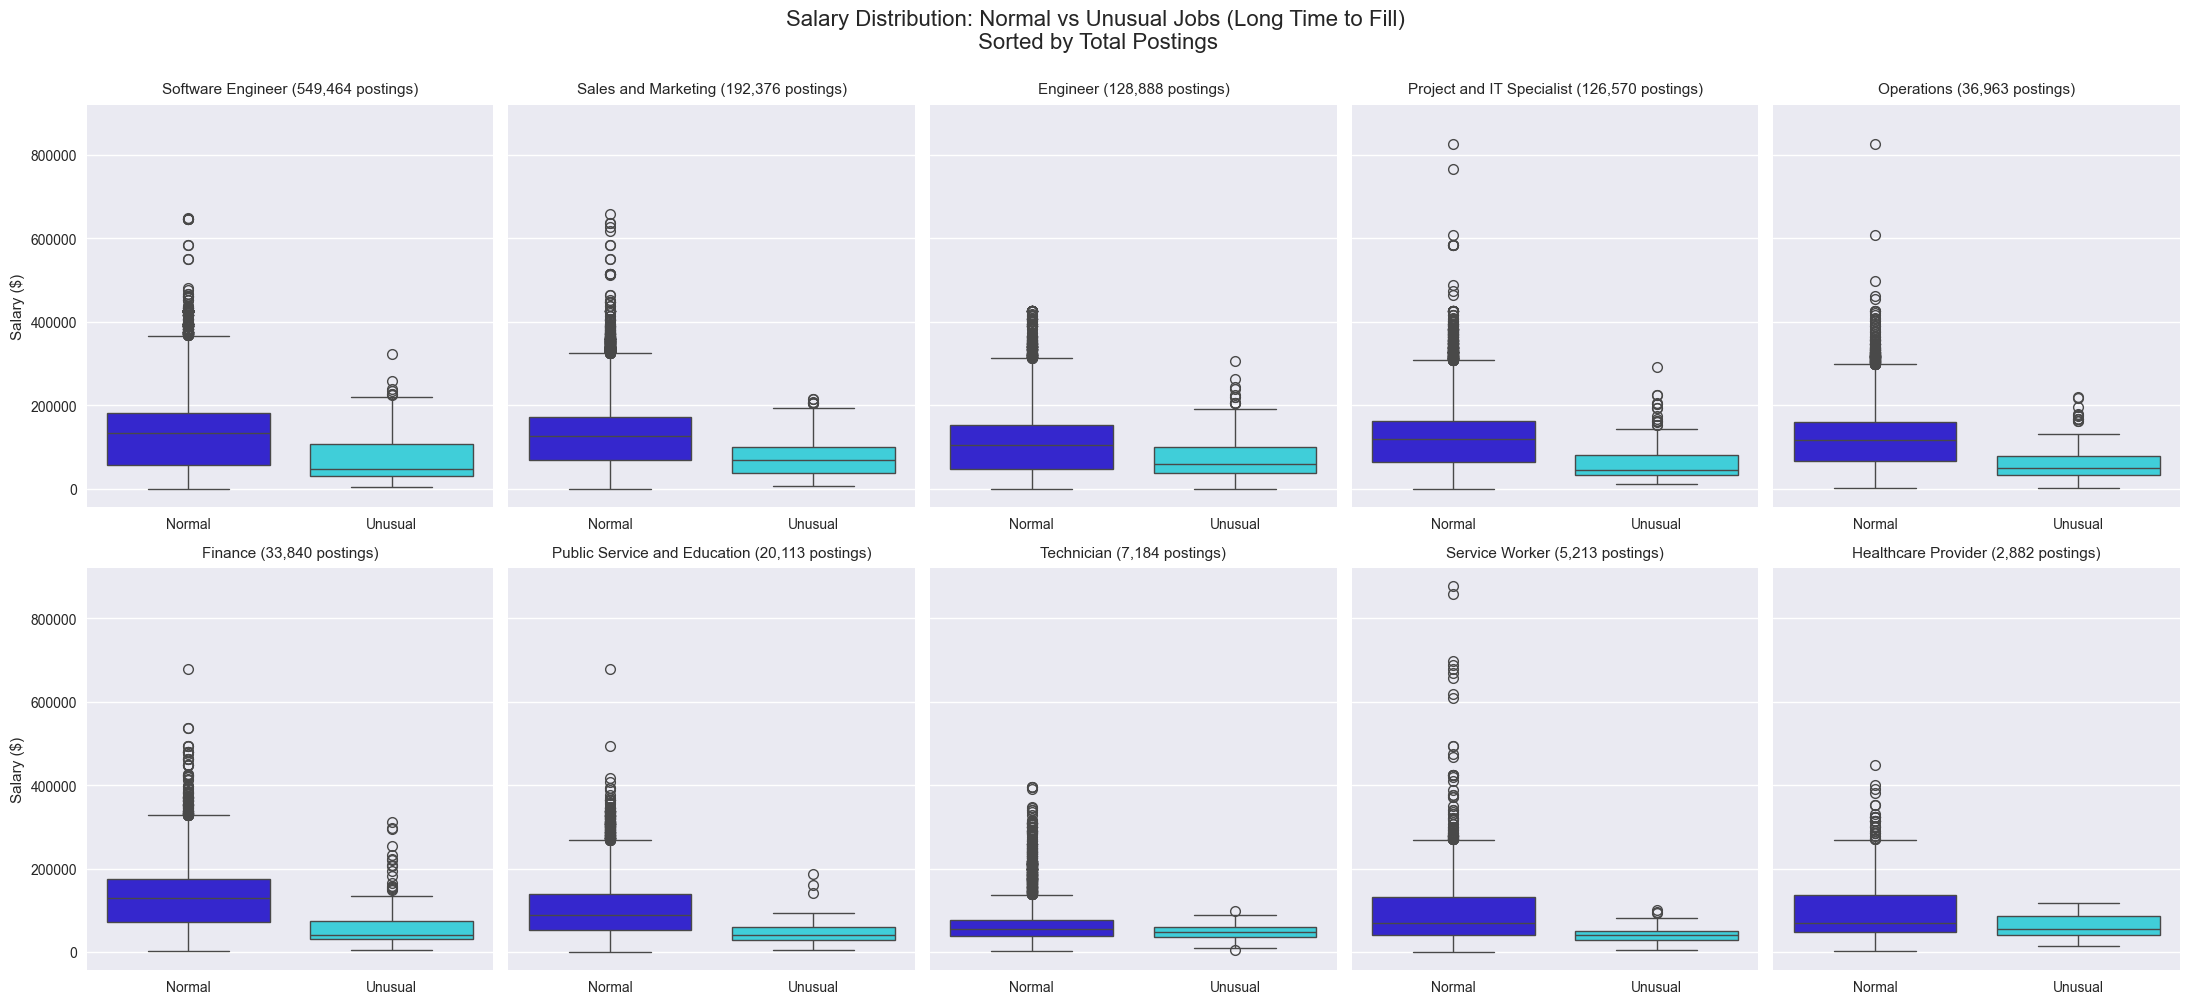

In [ ]:
# ================== Salary Distribution: Normal vs Outliers — Sorted by Total Postings ==================

# Get all 10 roles sorted by total number of postings (highest first)
role_order = df_clean['role_k10'].value_counts().index.tolist()

# ================== Subplots with shared Y-axis ==================
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for i, role in enumerate(role_order):
    ax = axes[i]
    data = df_clean[df_clean['role_k10'] == role].copy()
    
    # Mark outliers
    Q1 = data['filling_time_months'].quantile(0.25)
    Q3 = data['filling_time_months'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    data['is_outlier'] = data['filling_time_months'] > upper_bound
    
    sns.boxplot(
        data=data,
        x='is_outlier',
        y='salary',
        ax=ax,
        palette=["#1e0be9", "#27e4f2"]
    )
    
    ax.set_title(f"{role} ({data.shape[0]:,} postings)", fontsize=11, pad=8)
    ax.set_xlabel('')
    ax.set_xticklabels(['Normal', 'Unusual'])
    
    if i % 5 == 0:
        ax.set_ylabel("Salary ($)")
    else:
        ax.set_ylabel("")

# Hide any unused subplot (safety)
for j in range(len(role_order), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Salary Distribution: Normal vs Unusual Jobs (Long Time to Fill)\n Sorted by Total Postings", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

For Healthcare, Service Worker, Technician, and Public Service & Education roles, there are almost no high-salary outliers among jobs that take unusually long to fill.
This suggests these positions face a structural talent shortage: companies are not able (or willing) to use significantly higher pay to close the gap quickly. As a result, these roles tend to remain open longer.
The “HOWEVER” part is a great place to contrast with technical roles:
However, for Software Engineer and other technical roles, we see the opposite pattern: many long-to-fill positions come with very high salary outliers. This implies companies are aggressively using compensation to compete for scarce technical talent.

In [18]:
# === CREATE monthly_country (run this first) ===
import pandas as pd

# Aggregate average filling time by month + country
monthly_country = (
    df_clean.groupby(['Month', 'country'])['Filling_time_months']   # or whatever your time column is called
    .mean()
    .reset_index()
)

# Convert Period to datetime so matplotlib can plot it nicely
monthly_country['Month'] = monthly_country['Month'].dt.to_timestamp()

KeyError: 'Column not found: Filling_time_months'

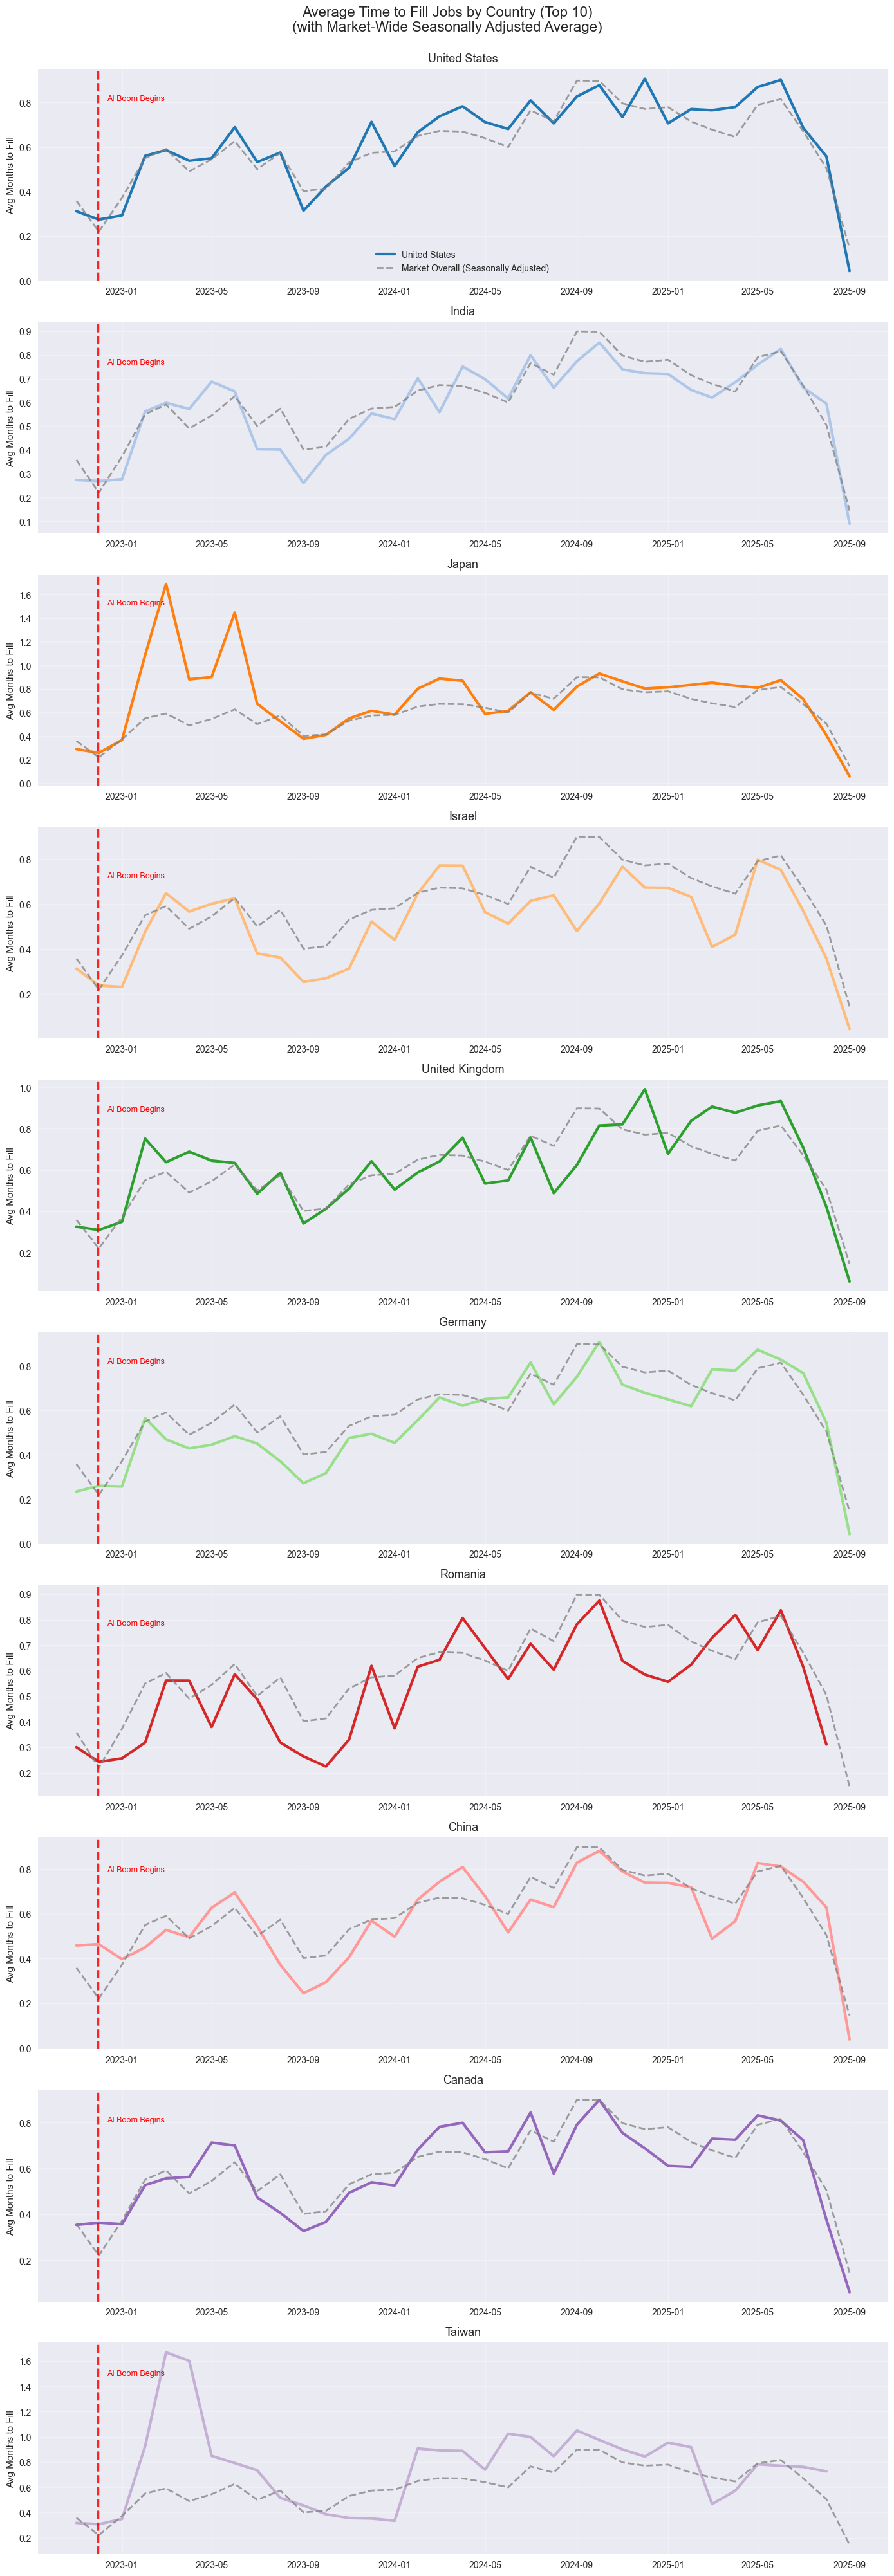

In [ ]:
# ================== Subplots by Country (Top 10) with same colors as big plot ==================

# Top 10 countries (same as big plot)
top_countries = df_clean['country'].value_counts().head(10).index.tolist()

# Use the same distinct color palette as the big plot
country_color_map = dict(zip(top_countries, colors))

# ================== Plot one subplot per country ==================
fig, axes = plt.subplots(len(top_countries), 1, figsize=(14, 4 * len(top_countries)), sharex=False)

for i, country in enumerate(top_countries):
    ax = axes[i]
    data = monthly_country[monthly_country['country'] == country]
    
    # Country-specific line (same color as in big plot)
    ax.plot(data['Month'], data['Filling_time_avg'], 
            label=country, linewidth=3, color=country_color_map[country])
    
    # Grey overall seasonally adjusted market line
    ax.plot(monthly_overall.index, monthly_overall['Filling_time_seasonally_adjusted'], 
            label='Market Overall (Seasonally Adjusted)', 
            linewidth=2, color='gray', alpha=0.75, linestyle='--')
    
    ax.set_title(f"{country}", fontsize=13, pad=8)
    ax.set_ylabel("Avg Months to Fill")
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend()

    # AI Boom marker
    if 2022 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2022, 11, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom Begins', xy=(datetime.datetime(2022, 11, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')

fig.suptitle("Average Time to Fill Jobs by Country (Top 10)\n(with Market-Wide Seasonally Adjusted Average)", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

# TO REVELIO LAB TEAM

I wanted to do an analysis not purely for a newsletter that economists would read but one that does two things:

1. gives us (as revelio labs) an insight into where we can find potential clients (those that still struggling with high ATF for roles can definitely benefit from our psuite of products)

2. those who read our newsletter and are actually in the HR industry. 

You see, these newsletters for people like us data scientists and economists is like reading AD as an architect: it definitely is insight, but it is something we already know how to find. 

But our clients don't know what they can do with data, what they can do with our products and what we can help them see in the "Blind spot" 
And so, although I am not an economist and despite knwoing that this model needs a lot of improvement, I wanted to submit this!

Here are some examples: if you look at the multi-plot graph from ATF a role in top 10 countries, you'll notice a country like Taiwan (although amongst top 10 countries) is still struglling with the wave of AI probably. This is our chance to do a deper dive into Taiwan job market and see where we can find clients!

(of course all these countries have a million other things influencing their job makrets and all but this could be a godo starting point)

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2521202646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


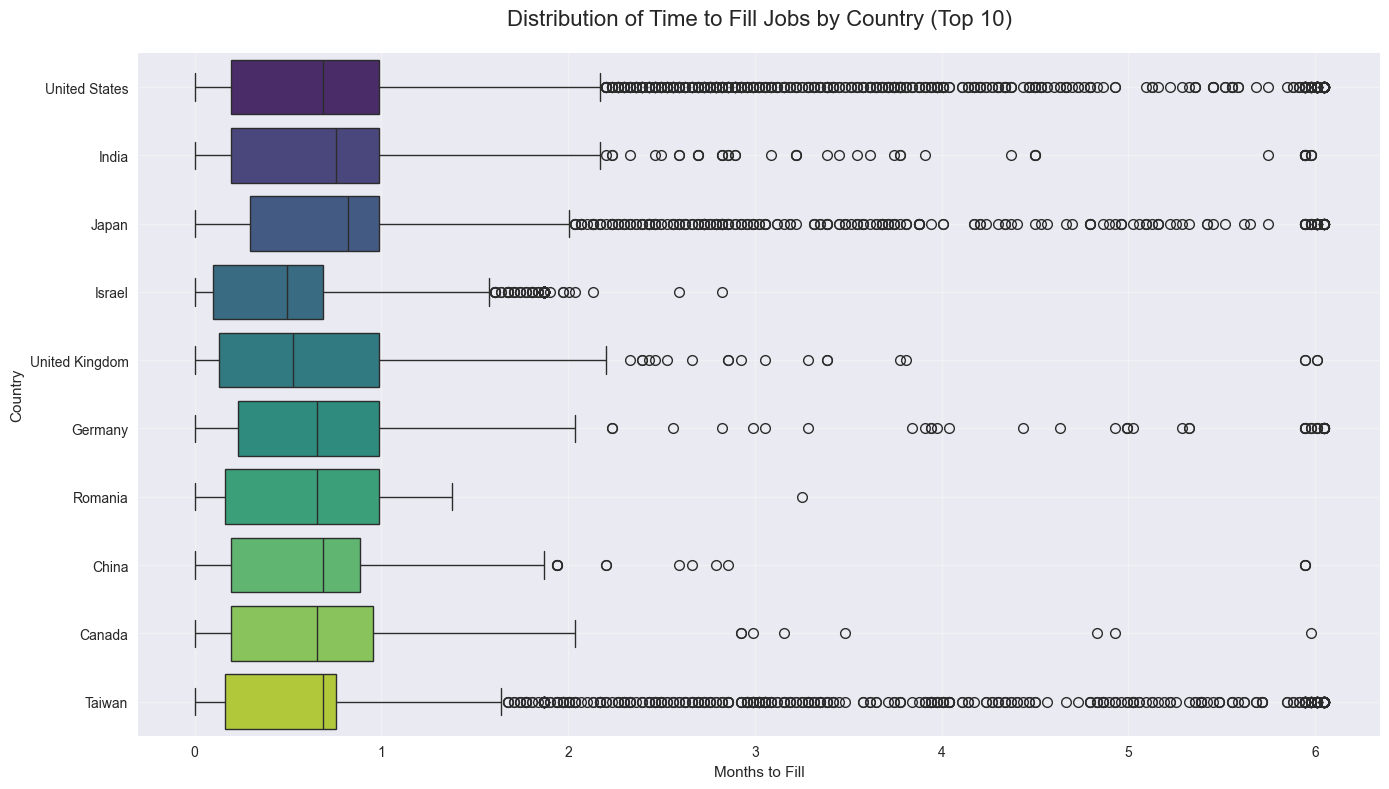

In [ ]:
# ================== Box Plot: Distribution of Filling Time by Country ==================

# Top 10 countries by number of postings
top_countries = df_clean['country'].value_counts().head(10).index.tolist()

# Filter data
plot_data = df_clean[df_clean['country'].isin(top_countries)].copy()

# ================== Box Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=plot_data,
    x='filling_time_months',
    y='country',
    order=top_countries,
    palette="viridis",
    showfliers=True
)

ax.set_title("Distribution of Time to Fill Jobs by Country (Top 10)", 
             fontsize=16, pad=20)
ax.set_xlabel("Months to Fill")
ax.set_ylabel("Country")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ================== Top 10 Countries — Role with Highest % of Outliers ==================

# Calculate outliers per country + role
outlier_counts = df_clean.groupby(['country', 'role_k10'])['filling_time_months'] \
    .apply(lambda x: (x > (x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum() if len(x) >= 4 else 0) \
    .reset_index(name='num_outliers')

# Total postings per country
total_per_country = df_clean.groupby('country').size().reset_index(name='total_postings')

# Merge and calculate percentage
result = outlier_counts.merge(total_per_country, on='country')
result['percentage'] = (result['num_outliers'] / result['total_postings'] * 100).round(2)

# For each country, keep the role with the highest % of outliers
top_outlier_role = result.loc[result.groupby('country')['percentage'].idxmax()]

# Filter to only Top 10 countries and sort
top_outlier_role = top_outlier_role[top_outlier_role['country'].isin(top_countries)]
top_outlier_role = top_outlier_role.sort_values('percentage', ascending=False)

print("Top 10 Countries — Role with Highest % of Outliers:\n")
print(top_outlier_role[['country', 'role_k10', 'num_outliers', 'total_postings', 'percentage']].to_string(index=False))

Top 10 Countries — Role with Highest % of Outliers:

       country            role_k10  num_outliers  total_postings  percentage
        Taiwan   Software Engineer           169           17379        0.97
        Israel   Software Engineer           151           24282        0.62
         Japan            Engineer           117           24823        0.47
        Canada Sales and Marketing            35           18943        0.18
         China Sales and Marketing            32           20422        0.16
       Germany            Engineer            22           23276        0.09
United Kingdom   Software Engineer            11           23975        0.05
 United States            Engineer           287          639131        0.04
         India             Finance            16          106505        0.02
       Romania            Engineer             1           20521        0.00
